# Tarea de Investigación y Práctica
## Práctica en Python

###Importar librerías necesarias

In [ ]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficas
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerías importadas correctamente")

Librerías importadas correctamente


###Cargar y preparar el dataset

In [ ]:
# Cargar el dataset breast_cancer
cancer = datasets.load_breast_cancer()
X = cancer.data
y = cancer.target

# Información del dataset
print(f"Dataset: Breast Cancer")
print(f"Número de muestras: {X.shape[0]}")
print(f"Número de características: {X.shape[1]}")
print(f"Clases: {np.unique(y)}")
print(f"Distribución de clases: {np.bincount(y)}")
print(f"\nCaracterísticas: {cancer.feature_names[:5]}")  # Mostrar algunas características

# Dividir en entrenamiento y prueba (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalizar los datos (importante para Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDataset preparado - Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Dataset: Breast Cancer
Número de muestras: 569
Número de características: 30
Clases: [0 1]
Distribución de clases: [212 357]

Características: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']

Dataset preparado - Train: (455, 30), Test: (114, 30)


## Preparación y división de los datos

In [ ]:
# Entrenar modelo de Regresión Logística
modelo_lr = LogisticRegression(max_iter=10000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

# Hacer predicciones
y_pred = modelo_lr.predict(X_test_scaled)
y_pred_proba = modelo_lr.predict_proba(X_test_scaled)[:, 1]  # Probabilidades para la clase positiva

print("Modelo de Regresión Logística entrenado correctamente")
print(f"Precisión en train: {modelo_lr.score(X_train_scaled, y_train):.4f}")
print(f"Precisión en test: {modelo_lr.score(X_test_scaled, y_test):.4f}")

Modelo de Regresión Logística entrenado correctamente
Precisión en train: 0.9890
Precisión en test: 0.9825


### Matriz de Confusión e Interpretación

Matriz de Confusión:
[[41  1]
 [ 1 71]]

Interpretación:
TN (Verdaderos Negativos): 41
FP (Falsos Positivos): 1
FN (Falsos Negativos): 1
TP (Verdaderos Positivos): 71


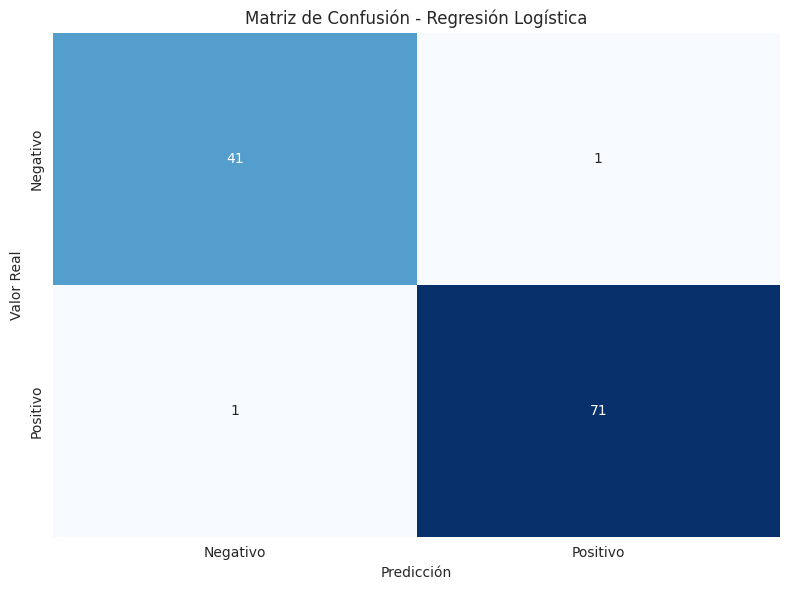

In [ ]:
# Generar matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusión:")
print(cm)
print(f"\nInterpretación:")
print(f"TN (Verdaderos Negativos): {cm[0, 0]}")
print(f"FP (Falsos Positivos): {cm[0, 1]}")
print(f"FN (Falsos Negativos): {cm[1, 0]}")
print(f"TP (Verdaderos Positivos): {cm[1, 1]}")

# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión - Regresión Logística')
plt.tight_layout()
plt.show()

### Calcular Métricas Principales

In [ ]:
# Calcular métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)
accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()

print("=========================================")
print("MÉTRICAS DE EVALUACIÓN DEL MODELO")
print("=========================================")
print(f"Exactitud (Accuracy):  {accuracy:.4f}")
print(f"Precisión:             {precision:.4f}")
print(f"Recall (Sensibilidad): {recall:.4f}")
print(f"F1-Score:              {f1:.4f}")
print(f"AUC-ROC:               {auc_roc:.4f}")
print("________________________________________")

# Guardar en un dataframe para comparación posterior
metricas_base = pd.DataFrame({
    'Modelo': ['Regresión Logística Básica'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1],
    'AUC-ROC': [auc_roc]
})

print("\nMétricas calculadas correctamente")

MÉTRICAS DE EVALUACIÓN DEL MODELO
Exactitud (Accuracy):  0.9825
Precisión:             0.9861
Recall (Sensibilidad): 0.9861
F1-Score:              0.9861
AUC-ROC:               0.9954
________________________________________

Métricas calculadas correctamente


### Curva ROC y cálculo del AUC

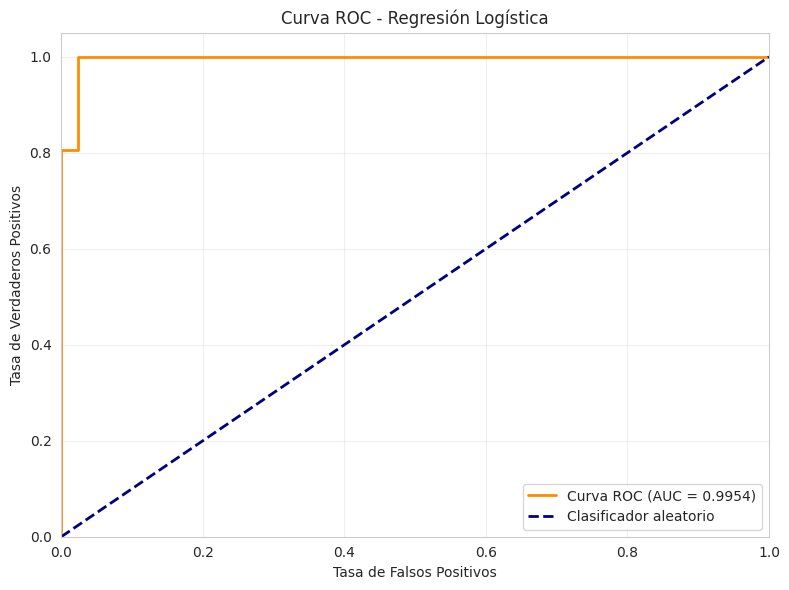

AUC-ROC: 0.9954


In [ ]:
# Generar datos para la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Visualizar curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")

### Validación cruzada con K-Fold (k = 5)

In [ ]:
# K-Fold con k=5
kfold_5 = KFold(n_splits=5, shuffle=True, random_state=42)
modelo_cv = LogisticRegression(max_iter=10000, random_state=42)

cv_scores_5 = cross_val_score(modelo_cv, X_train_scaled, y_train, cv=kfold_5, scoring='accuracy')

print("K-FOLD CROSS-VALIDATION (k=5)")
print(f"Scores por fold: {cv_scores_5.round(4)}")
print(f"Media: {cv_scores_5.mean():.4f}")
print(f"Desv. Estándar: {cv_scores_5.std():.4f}")

# K-Fold con k=10
kfold_10 = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_10 = cross_val_score(modelo_cv, X_train_scaled, y_train, cv=kfold_10, scoring='accuracy')

print("\nK-FOLD CROSS-VALIDATION (k=10)")
print(f"Scores por fold: {cv_scores_10.round(4)}")
print(f"Media: {cv_scores_10.mean():.4f}")
print(f"Desv. Estándar: {cv_scores_10.std():.4f}")

# Comparación
print("=========================================")
print("COMPARACIÓN K-FOLD")
print("=========================================")
print(f"k=5  -> Media: {cv_scores_5.mean():.4f} (±{cv_scores_5.std():.4f})")
print(f"k=10 -> Media: {cv_scores_10.mean():.4f} (±{cv_scores_10.std():.4f})")
print(f"\nDiferencia: {abs(cv_scores_5.mean() - cv_scores_10.mean()):.4f}")

K-FOLD CROSS-VALIDATION (k=5)
Scores por fold: [0.989  0.956  1.     0.978  0.9341]
Media: 0.9714
Desv. Estándar: 0.0237

K-FOLD CROSS-VALIDATION (k=10)
Scores por fold: [1.     1.     0.9348 0.9783 1.     0.9778 1.     0.9778 0.9333 0.9778]
Media: 0.9780
Desv. Estándar: 0.0241
COMPARACIÓN K-FOLD
k=5  -> Media: 0.9714 (±0.0237)
k=10 -> Media: 0.9780 (±0.0241)

Diferencia: 0.0065


### Búsqueda de mejores parámetros con GridSearchCV

In [ ]:
# Definir parámetros a buscar
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# GridSearchCV
print("Ejecutando GridSearchCV...")
grid_search = GridSearchCV(LogisticRegression(max_iter=10000, random_state=42),
                           param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("\nRESULTADOS GRIDSEARCHCV")
print("=========================================")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor score (CV): {grid_search.best_score_:.4f}")
print(f"Score en test: {grid_search.score(X_test_scaled, y_test):.4f}")

# Obtener predicciones con el mejor modelo
y_pred_grid = grid_search.predict(X_test_scaled)
precision_grid = precision_score(y_test, y_pred_grid)
recall_grid = recall_score(y_test, y_pred_grid)
f1_grid = f1_score(y_test, y_pred_grid)
auc_grid = roc_auc_score(y_test, grid_search.predict_proba(X_test_scaled)[:, 1])

print(f"Precision: {precision_grid:.4f}")
print(f"Recall: {recall_grid:.4f}")
print(f"F1-Score: {f1_grid:.4f}")
print(f"AUC-ROC: {auc_grid:.4f}")

Ejecutando GridSearchCV...

RESULTADOS GRIDSEARCHCV
Mejores parámetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor score (CV): 0.9802
Score en test: 0.9737
Precision: 0.9726
Recall: 0.9861
F1-Score: 0.9793
AUC-ROC: 0.9957


### Búsqueda aleatoria de hiperparámetros con RandomizedSearchCV

In [ ]:
# RandomizedSearchCV con los mismos parámetros
print("Ejecutando RandomizedSearchCV...")
random_search = RandomizedSearchCV(LogisticRegression(max_iter=10000, random_state=42),
                                   param_grid, cv=5, scoring='accuracy', n_iter=10, random_state=42, n_jobs=-1)
random_search.fit(X_train_scaled, y_train)

print("\nRESULTADOS RANDOMIZEDSEARCHCV")
print("=========================================")
print(f"Mejores parámetros: {random_search.best_params_}")
print(f"Mejor score (CV): {random_search.best_score_:.4f}")
print(f"Score en test: {random_search.score(X_test_scaled, y_test):.4f}")

# Obtener predicciones con el mejor modelo
y_pred_random = random_search.predict(X_test_scaled)
precision_random = precision_score(y_test, y_pred_random)
recall_random = recall_score(y_test, y_pred_random)
f1_random = f1_score(y_test, y_pred_random)
auc_random = roc_auc_score(y_test, random_search.predict_proba(X_test_scaled)[:, 1])

print(f"Precision: {precision_random:.4f}")
print(f"Recall: {recall_random:.4f}")
print(f"F1-Score: {f1_random:.4f}")
print(f"AUC-ROC: {auc_random:.4f}")

Ejecutando RandomizedSearchCV...

RESULTADOS RANDOMIZEDSEARCHCV
Mejores parámetros: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}
Mejor score (CV): 0.9802
Score en test: 0.9737
Precision: 0.9726
Recall: 0.9861
F1-Score: 0.9793
AUC-ROC: 0.9957


### Comparación GridSearchCV vs RandomizedSearchCV

In [ ]:
# Comparar eficiencia
print("=========================================")
print("COMPARACIÓN: GridSearchCV vs RandomizedSearchCV")
print("=========================================")
print(f"\nGridSearchCV:")
print(f"  - Parámetros evaluados: {len(grid_search.cv_results_['params'])}")
print(f"  - Score CV: {grid_search.best_score_:.4f}")
print(f"  - Score Test: {grid_search.score(X_test_scaled, y_test):.4f}")

print(f"\nRandomizedSearchCV:")
print(f"  - Parámetros evaluados: {len(random_search.cv_results_['params'])}")
print(f"  - Score CV: {random_search.best_score_:.4f}")
print(f"  - Score Test: {random_search.score(X_test_scaled, y_test):.4f}")

# Tabla de comparación
comparacion_busqueda = pd.DataFrame({
    'Método': ['GridSearchCV', 'RandomizedSearchCV'],
    'Parámetros Evaluados': [len(grid_search.cv_results_['params']), len(random_search.cv_results_['params'])],
    'Score CV': [grid_search.best_score_, random_search.best_score_],
    'Score Test': [grid_search.score(X_test_scaled, y_test), random_search.score(X_test_scaled, y_test)],
    'F1-Score': [f1_grid, f1_random],
    'AUC-ROC': [auc_grid, auc_random]
})

print("\n" + comparacion_busqueda.to_string(index=False))

COMPARACIÓN: GridSearchCV vs RandomizedSearchCV

GridSearchCV:
  - Parámetros evaluados: 12
  - Score CV: 0.9802
  - Score Test: 0.9737

RandomizedSearchCV:
  - Parámetros evaluados: 10
  - Score CV: 0.9802
  - Score Test: 0.9737

            Método  Parámetros Evaluados  Score CV  Score Test  F1-Score  AUC-ROC
      GridSearchCV                    12   0.98022    0.973684   0.97931 0.995701
RandomizedSearchCV                    10   0.98022    0.973684   0.97931 0.995701


### Ajuste del Umbral de Decisión

In [ ]:
# Analizar el impacto del umbral de decisión
umbrales = [0.3, 0.4, 0.5, 0.6, 0.7]
resultados_umbral = []

print("\nIMPACTO DEL AJUSTE DEL UMBRAL DE DECISIÓN")
print("=========================================================================")
print(f"{'Umbral':<10} {'Precision':<15} {'Recall':<15} {'F1-Score':<15} {'Accuracy':<15}")
print("=========================================================================")

for umbral in umbrales:
    # Generar predicciones con nuevo umbral
    y_pred_umbral = (y_pred_proba >= umbral).astype(int)

    # Calcular métricas
    precision_u = precision_score(y_test, y_pred_umbral, zero_division=0)
    recall_u = recall_score(y_test, y_pred_umbral, zero_division=0)
    f1_u = f1_score(y_test, y_pred_umbral, zero_division=0)
    accuracy_u = (y_test == y_pred_umbral).sum() / len(y_test)

    print(f"{umbral:<10.1f} {precision_u:<15.4f} {recall_u:<15.4f} {f1_u:<15.4f} {accuracy_u:<15.4f}")

    resultados_umbral.append({
        'Umbral': umbral,
        'Precision': precision_u,
        'Recall': recall_u,
        'F1-Score': f1_u,
        'Accuracy': accuracy_u
    })

print("=========================================================================")
df_umbral = pd.DataFrame(resultados_umbral)


IMPACTO DEL AJUSTE DEL UMBRAL DE DECISIÓN
Umbral     Precision       Recall          F1-Score        Accuracy       
0.3        0.9730          1.0000          0.9863          0.9825         
0.4        0.9861          0.9861          0.9861          0.9825         
0.5        0.9861          0.9861          0.9861          0.9825         
0.6        0.9855          0.9444          0.9645          0.9561         
0.7        0.9853          0.9306          0.9571          0.9474         


### Visualizar el Impacto del Umbral

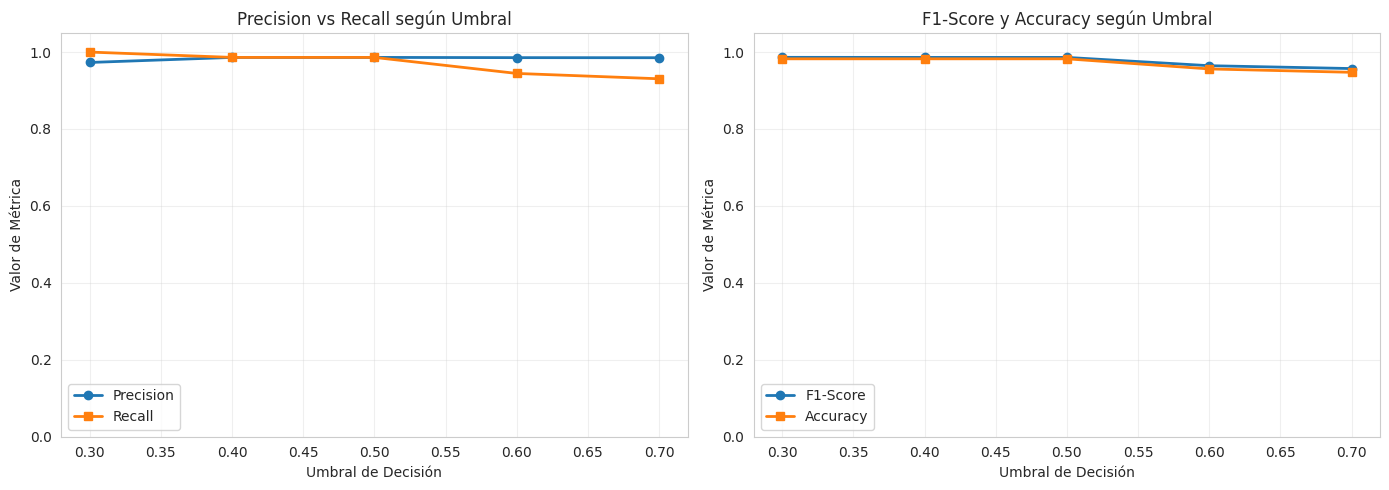

Análisis del impacto del umbral completado


In [ ]:
# Gráfica del impacto del umbral
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Precision vs Recall
ax1.plot(df_umbral['Umbral'], df_umbral['Precision'], marker='o', label='Precision', linewidth=2)
ax1.plot(df_umbral['Umbral'], df_umbral['Recall'], marker='s', label='Recall', linewidth=2)
ax1.set_xlabel('Umbral de Decisión')
ax1.set_ylabel('Valor de Métrica')
ax1.set_title('Precision vs Recall según Umbral')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1.05])

# Gráfica 2: Todas las métricas
ax2.plot(df_umbral['Umbral'], df_umbral['F1-Score'], marker='o', label='F1-Score', linewidth=2)
ax2.plot(df_umbral['Umbral'], df_umbral['Accuracy'], marker='s', label='Accuracy', linewidth=2)
ax2.set_xlabel('Umbral de Decisión')
ax2.set_ylabel('Valor de Métrica')
ax2.set_title('F1-Score y Accuracy según Umbral')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("Análisis del impacto del umbral completado")

### Resumen Final de Resultados

In [ ]:
# Resumen de todos los modelos evaluados
print("================================================================================")
print("RESUMEN FINAL: COMPARACIÓN DE TODOS LOS MODELOS")
print("================================================================================")

resumen_final = pd.DataFrame({
    'Modelo': [
        'Reg. Logística Básica',
        'GridSearchCV (Optimizado)',
        'RandomizedSearchCV (Optimizado)'
    ],
    'Accuracy': [
        accuracy,
        grid_search.score(X_test_scaled, y_test),
        random_search.score(X_test_scaled, y_test)
    ],
    'Precision': [precision, precision_grid, precision_random],
    'Recall': [recall, recall_grid, recall_random],
    'F1-Score': [f1, f1_grid, f1_random],
    'AUC-ROC': [auc_roc, auc_grid, auc_random]
})

print("\n" + resumen_final.to_string(index=False))
print("================================================================================")

# Mejoras
mejora_grid = ((grid_search.score(X_test_scaled, y_test) - accuracy) / accuracy) * 100
mejora_random = ((random_search.score(X_test_scaled, y_test) - accuracy) / accuracy) * 100

print(f"\nMejora de GridSearchCV: {mejora_grid:+.2f}%")
print(f"Mejora de RandomizedSearchCV: {mejora_random:+.2f}%")
print("\nAnálisis completado exitosamente")

RESUMEN FINAL: COMPARACIÓN DE TODOS LOS MODELOS

                         Modelo  Accuracy  Precision   Recall  F1-Score  AUC-ROC
          Reg. Logística Básica  0.982456   0.986111 0.986111  0.986111 0.995370
      GridSearchCV (Optimizado)  0.973684   0.972603 0.986111  0.979310 0.995701
RandomizedSearchCV (Optimizado)  0.973684   0.972603 0.986111  0.979310 0.995701

Mejora de GridSearchCV: -0.89%
Mejora de RandomizedSearchCV: -0.89%

Análisis completado exitosamente
